In [1]:
!git clone https://github.com/jordan-bird/CIFAKE-Real-and-AI-Generated-Synthetic-Images.git

Cloning into 'CIFAKE-Real-and-AI-Generated-Synthetic-Images'...
remote: Enumerating objects: 118694, done.
remote: Counting objects: 100% (118694/118694), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 118694 (delta 118651), reused 118673 (delta 118645), pack-reused 0 (from 0)
Receiving objects: 100% (118694/118694), 39.68 MiB | 7.40 MiB/s, done.
Resolving deltas: 100% (118651/118651), done.
Updating files: 100% (120001/120001), done.


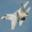

In [2]:

from IPython.display import Image, display

display(Image(filename='./CIFAKE-Real-and-AI-Generated-Synthetic-Images/DATASET/test/REAL/0001.jpg', width=400))


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from PIL import Image
import torch.nn.functional as F
from datetime import datetime
from tqdm import tqdm

# ---------------------------------------------------------
# 1) CONFIGURATION
# ---------------------------------------------------------
DATA_DIR = "/mnt/scratch/Stable_diffusion/Stable_diffusion_ready"
BATCH_SIZE = 256
LR = 1e-3
EPOCHS = 20
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

torch.backends.cudnn.benchmark = True

# Model hyperparameters (from paper search space)
CONV_FILTERS = 32          # {16, 32, 64, 128}
CONV_LAYERS = 2            # {1, 2, 3}
DENSE_NEURONS = 64         # {32, 64, 128, 256, 512, 1024, 2048, 4096}
DENSE_LAYERS = 1           # {1, 2, 3}

# Grad-CAM / output config
OUT_DIR = "/home/cv04f26/ComputerVisionProject/gradcam_outputs"
NUM_CAM_SAMPLES = 12
IMAGE_SIZE = 256

print(DEVICE)

# ---------------------------------------------------------
# 2) DATA PIPELINE (torchvision.io + tensor-native transforms)
# ---------------------------------------------------------
# Prefer torchvision v2 transforms; fallback to functional if v2 missing.
_use_v2 = False
tensor_transform = None

try:
    import torchvision.transforms.v2 as T
    from torchvision.transforms import InterpolationMode
    _use_v2 = True
    tensor_transform = T.Compose([
        T.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=InterpolationMode.BILINEAR, antialias=True),
        T.ToDtype(torch.float32, scale=True),  # scales uint8 -> float32 [0,1]
    ])
except Exception:
    from torchvision.transforms import InterpolationMode
    from torchvision.transforms import functional as TF

    def tensor_transform(img: torch.Tensor) -> torch.Tensor:
        # img: Tensor uint8 [C,H,W]
        img = TF.resize(img, [IMAGE_SIZE, IMAGE_SIZE],
                        interpolation=InterpolationMode.BILINEAR, antialias=True)
        img = img.float() / 255.0
        return img

class SafeImageFolder(datasets.ImageFolder):
    """
    Faster loader using torchvision.io.read_image (no PIL for reading).
    - Ensures 3 channels (expand grayscale, drop alpha)
    - Applies tensor-native transforms
    - Skips corrupted/unreadable images (returns None)
    """
    def __init__(self, root, transform=None):
        super().__init__(root, transform=transform)

    def __getitem__(self, index):
        path, target = self.samples[index]
        try:
            img = read_image(path)  # uint8 tensor [C,H,W]
            if img.ndim != 3:
                return None
            # Normalize channels to 3 (RGB-like)
            if img.shape[0] == 1:
                img = img.expand(3, -1, -1)      # grayscale -> 3-ch
            elif img.shape[0] > 3:
                img = img[:3, ...]               # drop alpha/extras

            if self.transform is not None:
                img = self.transform(img)
            else:
                img = img.float() / 255.0

            return img, target
        except (RuntimeError, OSError, ValueError):
            # read_image raises RuntimeError for decode errors
            return None  # mark as bad

# Collate function to remove None samples
def collate_skip_none(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None
    imgs, labels = zip(*batch)
    return torch.utils.data.dataloader.default_collate(list(zip(imgs, labels)))

train_data = SafeImageFolder(os.path.join(DATA_DIR, "train"), transform=tensor_transform)
test_data  = SafeImageFolder(os.path.join(DATA_DIR, "val"),   transform=tensor_transform)
print(DEVICE)
pin_mem = (DEVICE == "cuda")

train_loader = DataLoader(
    train_data, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=16, persistent_workers=True, prefetch_factor=8,
    pin_memory=pin_mem, collate_fn=collate_skip_none
)
test_loader  = DataLoader(
    test_data, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=16, persistent_workers=True, prefetch_factor=8,
    pin_memory=pin_mem, collate_fn=collate_skip_none
)

idx_to_class = {v: k for k, v in train_data.class_to_idx.items()}   # e.g., 0: AI, 1: REAL

# ---------------------------------------------------------
# 3) MODEL DEFINITION (returns logits; no Sigmoid in forward)
# ---------------------------------------------------------
class CIFAKE_CNN(nn.Module):
    def __init__(self, conv_filters, conv_layers, dense_neurons, dense_layers):
        super().__init__()

        conv_blocks = []
        in_channels = 3

        for _ in range(conv_layers):
            conv_blocks.append(nn.Conv2d(in_channels, conv_filters, kernel_size=3, stride=1, padding=1))
            conv_blocks.append(nn.ReLU())
            conv_blocks.append(nn.MaxPool2d(kernel_size=2, stride=2))
            in_channels = conv_filters

        self.conv = nn.Sequential(*conv_blocks)
        reduction = 2 ** conv_layers
        flattened_size = (IMAGE_SIZE // reduction) * (IMAGE_SIZE // reduction) * conv_filters

        dense_blocks = []
        in_features = flattened_size

        for _ in range(dense_layers):
            dense_blocks.append(nn.Linear(in_features, dense_neurons))
            dense_blocks.append(nn.ReLU())
            in_features = dense_neurons

        dense_blocks.append(nn.Linear(in_features, 1))   # binary logit
        self.fc_logits = nn.Sequential(*dense_blocks)

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        logit = self.fc_logits(x)
        return logit  # (B,1) logits

    def forward_logits(self, x):
        return self.forward(x)

model = CIFAKE_CNN(CONV_FILTERS, CONV_LAYERS, DENSE_NEURONS, DENSE_LAYERS).to(DEVICE)

# Use logits-safe, autocast-safe BCEWithLogitsLoss
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scaler = GradScaler(enabled=(DEVICE == "cuda"))

# ---------------------------------------------------------
# 4) TRAINING / EVAL
# ---------------------------------------------------------
# def train_one_epoch(epoch):
#     model.train()
#     running_loss = 0.0


#     for images, labels in train_loader:
#         images = images.to(DEVICE)
#         labels = labels.float().unsqueeze(1).to(DEVICE)

#         optimizer.zero_grad()
#         outputs = model(images)                 # probabilities
#         loss = criterion(outputs, labels)

#         loss.backward()
#         optimizer.step()

#         running_loss += loss.item()

#     print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {running_loss / len(train_loader):.4f}")

def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    steps = 0

    # Wrap the train_loader with tqdm
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)

    for images, labels in loop:
        images = images.to(DEVICE)
        labels = labels.float().unsqueeze(1).to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=DEVICE, dtype=torch.float16, enabled=(DEVICE == "cuda")):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        steps += 1
        loop.set_postfix(loss=(running_loss / max(steps, 1)))

        # Update tqdm postfix to show current loss
        loop.set_postfix(loss=running_loss / (loop.n + 1))

    # Print average loss after epoch
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {running_loss / len(train_loader):.4f}")

def evaluate():
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        with autocast(device_type=DEVICE, dtype=torch.float16, enabled=(DEVICE == "cuda")):
            for batch in test_loader:
                if batch is None:
                    continue
                images, labels = batch
                images = images.to(DEVICE, non_blocking=True)
                logits = model(images)
                probs = torch.sigmoid(logits)

                predictions = (probs.float().cpu().numpy() > 0.5).astype(int)
                preds.extend(predictions.flatten())
                trues.extend(labels.numpy().flatten())

    if len(preds) == 0:
        print("\n--- TEST RESULTS ---")
        print("No valid samples to evaluate.")
        return 0, 0, 0, 0

    accuracy  = np.mean(np.array(preds) == np.array(trues))
    precision = precision_score(trues, preds, zero_division=0)
    recall    = recall_score(trues, preds, zero_division=0)
    f1        = f1_score(trues, preds, zero_division=0)

    print("\n--- TEST RESULTS ---")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    return accuracy, precision, recall, f1

# ---------------------------------------------------------
# 5) GRAD-CAM IMPLEMENTATION
# ---------------------------------------------------------
def find_last_conv_layer(module: nn.Module):
    last_conv = None
    for m in module.modules():
        if isinstance(m, nn.Conv2d):
            last_conv = m
    if last_conv is None:
        raise RuntimeError("No Conv2d layer found for Grad-CAM.")
    return last_conv

class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        def forward_hook(module, inputs, output):
            self.activations = output.detach()

        def full_backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.fwd_handle = self.target_layer.register_forward_hook(forward_hook)

        self.bwd_handle = self.target_layer.register_full_backward_hook(full_backward_hook)

    def remove_hooks(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

    @torch.no_grad()
    def _normalize_cam(self, cam):
        B, H, W = cam.shape
        cam = cam.view(B, -1)
        cam_min = cam.min(dim=1, keepdim=True).values
        cam_max = cam.max(dim=1, keepdim=True).values
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-6)
        return cam.view(B, H, W)

    def generate(self, input_tensor: torch.Tensor, use_logits: bool = True):
        self.model.zero_grad()
        if use_logits and hasattr(self.model, "forward_logits"):
            output = self.model.forward_logits(input_tensor)     # (B,1) logits
            target = output.squeeze(1)
        else:
            output = self.model(input_tensor)                    # (B,1) logits
            target = output.squeeze(1)
        target.sum().backward()
        grads = self.gradients            # (B, C, H, W)
        activs = self.activations         # (B, C, H, W)
        weights = grads.mean(dim=(2, 3), keepdim=True)  # (B, C, 1, 1)
        cam = (weights * activs).sum(dim=1)            # (B, H, W)
        cam = torch.relu(cam)
        cam = self._normalize_cam(cam)
        cam = cam.unsqueeze(1)
        cam = F.interpolate(cam, size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False).squeeze(1)
        return cam  # (B,IMAGE_SIZE,IMAGE_SIZE) in [0,1]

# ---------------------------------------------------------
# 6) VISUALIZATION UTILITIES (PIL only for saving)
# ---------------------------------------------------------
def to_uint8_img(t: torch.Tensor):
    t = t.detach().cpu().clamp(0, 1)
    arr = (t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    return arr

def colorize_cam(cam_2d: np.ndarray, cmap_name="jet"):
    colormap = cm.get_cmap(cmap_name)
    heatmap = colormap(cam_2d)[:, :, :3]
    return heatmap.astype(np.float32)

def overlay_heatmap_on_image(img_uint8: np.ndarray, heatmap_rgb: np.ndarray, alpha=0.5):
    img_float = img_uint8.astype(np.float32) / 255.0
    overlay = heatmap_rgb * alpha + img_float * (1 - alpha)
    overlay = (np.clip(overlay, 0, 1) * 255).astype(np.uint8)
    return overlay

def save_triplet(input_img, heatmap_img, overlay_img, prefix, out_dir, upscale=IMAGE_SIZE):
    os.makedirs(out_dir, exist_ok=True)
    inp = Image.fromarray(input_img).resize((upscale, upscale), Image.NEAREST)
    htm = Image.fromarray((heatmap_img * 255).astype(np.uint8)).resize((upscale, upscale), Image.NEAREST)
    ovl = Image.fromarray(overlay_img).resize((upscale, upscale), Image.NEAREST)
    inp.save(os.path.join(out_dir, f"{prefix}_input.png"))
    htm.save(os.path.join(out_dir, f"{prefix}_heatmap.png"))
    ovl.save(os.path.join(out_dir, f"{prefix}_overlay.png"))

def generate_gradcam_samples(n_samples=NUM_CAM_SAMPLES):
    model.eval()
    last_conv = find_last_conv_layer(model)
    cam = GradCAM(model, last_conv)

    saved = 0
    stamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    base_out = os.path.join(OUT_DIR, stamp)
    os.makedirs(base_out, exist_ok=True)

    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            if saved >= n_samples:
                break
            if batch is None:
                continue

            images, labels = batch
            images = images.to(DEVICE, non_blocking=True)

            with autocast(device_type=DEVICE, dtype=torch.float16, enabled=(DEVICE == "cuda")):
                logits = model(images)
                probs = torch.sigmoid(logits)

            preds = (probs > 0.5).long().squeeze(1).cpu()

            for i in range(images.size(0)):
                if saved >= n_samples:
                    break

                label = int(labels[i].item())
                pred  = int(preds[i].item())

                with torch.enable_grad():
                    img = images[i].unsqueeze(0).detach().to(DEVICE)
                    img.requires_grad_(True)
                    with autocast(device_type=DEVICE, dtype=torch.float16, enabled=(DEVICE == "cuda")):
                        cam_map = cam.generate(img, use_logits=True)[0].cpu().numpy()

                input_u8   = to_uint8_img(images[i])
                heat_rgb   = colorize_cam(cam_map, cmap_name="jet")
                overlay_u8 = overlay_heatmap_on_image(input_u8, heat_rgb, alpha=0.55)

                prefix = f"idx{batch_idx:03d}_{i:02d}_true-{idx_to_class[label]}_pred-{idx_to_class[pred]}"
                save_triplet(input_u8, heat_rgb, overlay_u8, prefix, base_out, upscale=IMAGE_SIZE)

                saved += 1

    cam.remove_hooks()
    print(f"\n[Grad-CAM] Saved {saved} visualizations to: {base_out}")

# ---------------------------------------------------------
# 7) MAIN
# ---------------------------------------------------------
if __name__ == "__main__":
    print(model)
    for epoch in range(EPOCHS):
        train_one_epoch(epoch)
    evaluate()
    generate_gradcam_samples(NUM_CAM_SAMPLES)

CIFAKE_CNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_logits): Sequential(
    (0): Linear(in_features=2048, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (prob): Sigmoid()
)


Epoch 1/20:   0%|          | 0/782 [00:00<?, ?it/s]/home/cv04f26/.conda/envs/tankenv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/20 | Loss: 0.3641


Epoch 2/20 | Loss: 0.2440


Epoch 3/20:  20%|█▉        | 153/782 [00:11<00:30, 20.82it/s, loss=0.215]

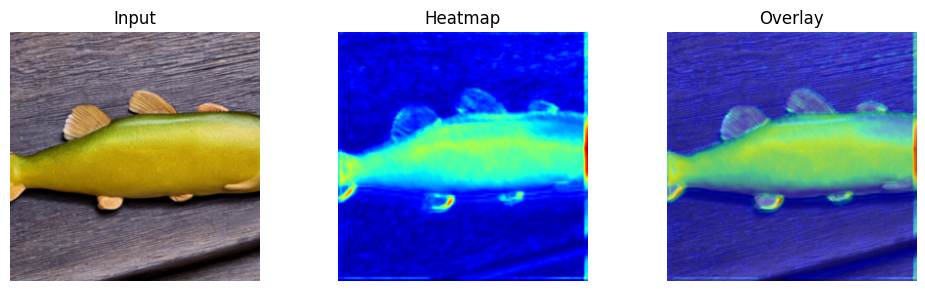

In [27]:

import os, glob
from PIL import Image
import matplotlib.pyplot as plt

folder = sorted(glob.glob("gradcam_outputs/*"))[-1]  # latest run
triplets = sorted(glob.glob(os.path.join(folder, "*_overlay.png")))

def show_triplet(overlay_path):
    prefix = overlay_path.replace("_overlay.png", "")
    inp = Image.open(prefix + "_input.png")
    htm = Image.open(prefix + "_heatmap.png")
    ovl = Image.open(overlay_path)

    plt.figure(figsize=(10, 3))
    plt.subplot(1, 3, 1); plt.imshow(inp); plt.axis("off"); plt.title("Input")
    plt.subplot(1, 3, 2); plt.imshow(htm); plt.axis("off"); plt.title("Heatmap")
    plt.subplot(1, 3, 3); plt.imshow(ovl); plt.axis("off"); plt.title("Overlay")
    plt.tight_layout(); plt.show()

show_triplet(triplets[0])  # visualize the first saved example


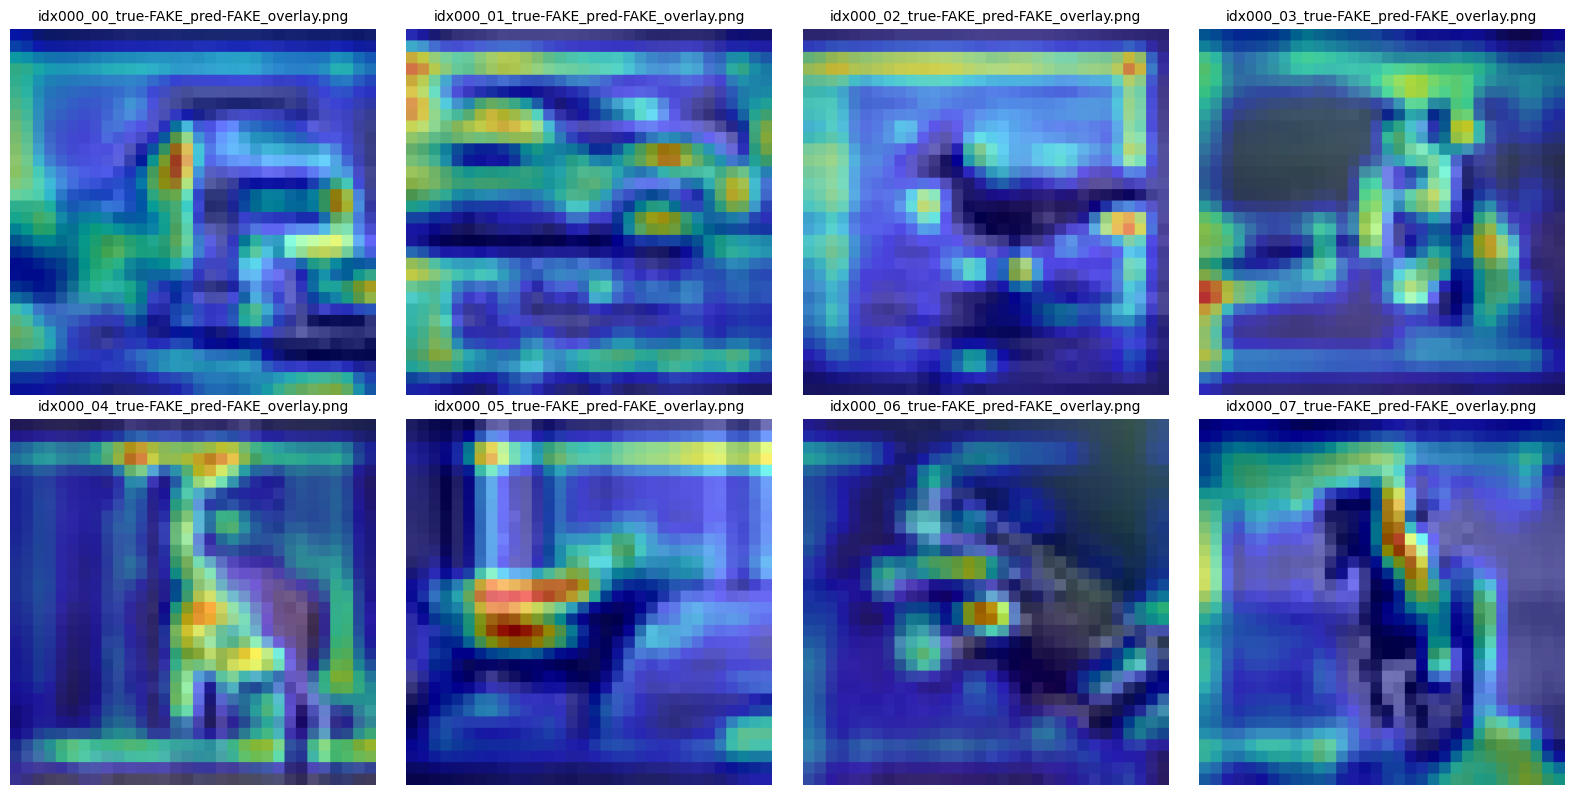

In [11]:
import math

N = 8  # how many examples to show
paths = sorted(glob.glob(os.path.join(folder, "*_overlay.png")))[:N]
cols = 4
rows = math.ceil(N / cols)

plt.figure(figsize=(4*cols, 4*rows))
for i, p in enumerate(paths):
    plt.subplot(rows, cols, i+1)
    plt.imshow(Image.open(p))
    plt.axis("off")
    plt.title(os.path.basename(p), fontsize=10)
plt.tight_layout(); plt.show()
